<a href="https://colab.research.google.com/github/Ajwad07/ML_projects_/blob/main/image_recontruction_with_only_images_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adityajn105_flickr8k_path = kagglehub.dataset_download('adityajn105/flickr8k')

print('Data source import complete.')

Data source import complete.


In [2]:
# ====================================================
# Image Deblurring Pipeline - Full Notebook
# ====================================================

# =====================
# 1. Imports
# =====================
import os
import cv2
import numpy as np
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from skimage.metrics import peak_signal_noise_ratio, structural_similarity


In [3]:
# =============================
# 1. Setup & Imports
# =============================
import os, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric


In [4]:
# =============================
# 2. Config
# =============================
class CFG:
    seed = 42
    image_dir = "/kaggle/input/flickr8k/Images"   # <-- adjust if needed
    caption_file = "/kaggle/input/flickr8k/captions.txt"  # not used here
    img_size = 128
    batch_size = 16
    num_workers = 2
    lr = 1e-3
    epochs = 10
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8
    subset_size = None  # for quick training


In [5]:
# =============================
# 3. Seed
# =============================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)


In [6]:
# =============================
# 4. Dataset
# =============================
class BlurDataset(Dataset):
    def __init__(self, image_dir, img_size=128, subset_size=None, split="train"):
        self.img_dir = image_dir
        self.img_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

        if subset_size:
            self.img_files = self.img_files[:subset_size]

        split_idx = int(len(self.img_files) * CFG.train_split)
        if split == "train":
            self.img_files = self.img_files[:split_idx]
        else:
            self.img_files = self.img_files[split_idx:]

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = Image.open(img_path).convert("RGB")
        sharp = self.transform(img)
        blur = img.filter(ImageFilter.GaussianBlur(radius=6))
        blur = self.transform(blur)
        return blur, sharp


In [8]:
# =============================
# 4. Dataset
# =============================
class BlurDataset(Dataset):
    def __init__(self, image_dir, img_size=128, subset_size=None, split="train"):
        self.img_dir = image_dir
        self.img_files = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]

        if subset_size:
            self.img_files = self.img_files[:subset_size]

        split_idx = int(len(self.img_files) * CFG.train_split)
        if split == "train":
            self.img_files = self.img_files[:split_idx]
        else:
            self.img_files = self.img_files[split_idx:]

        self.transform = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),
        ])

    def __len__(self): return len(self.img_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_files[idx])
        img = Image.open(img_path).convert("RGB")
        sharp = self.transform(img)
        blur = img.filter(ImageFilter.GaussianBlur(radius=4))
        blur = self.transform(blur)
        return blur, sharp


In [9]:
# =============================
# 5. Dataloaders
# =============================
train_ds = BlurDataset(CFG.image_dir, CFG.img_size, CFG.subset_size, "train")
val_ds   = BlurDataset(CFG.image_dir, CFG.img_size, CFG.subset_size, "val")

train_loader = DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True, num_workers=CFG.num_workers)
val_loader   = DataLoader(val_ds, batch_size=CFG.batch_size, shuffle=False, num_workers=CFG.num_workers)

print("Train:", len(train_ds), "Val:", len(val_ds))


Train: 6472 Val: 1619


In [10]:
# =============================
# 6. Model (U-Net Small)
# =============================
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(3, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ConvBlock(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        self.outc = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        d2 = self.up2(e3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))
        return torch.sigmoid(self.outc(d1))


In [11]:
# =============================
# 7. Training Utils
# =============================
def psnr(pred, target):
    pred = pred.detach().cpu().numpy().transpose(0,2,3,1)
    target = target.detach().cpu().numpy().transpose(0,2,3,1)
    return np.mean([psnr_metric(t, p, data_range=1.0) for p,t in zip(pred,target)])

def ssim(pred, target):
    pred = pred.detach().cpu().numpy().transpose(0,2,3,1)
    target = target.detach().cpu().numpy().transpose(0,2,3,1)
    return np.mean([ssim_metric(t, p, channel_axis=-1, data_range=1.0) for p,t in zip(pred,target)])

def show_examples(model, loader, n=3):
    model.eval()
    imgs = next(iter(loader))
    blur, sharp = imgs
    blur, sharp = blur.to(CFG.device), sharp.to(CFG.device)
    with torch.no_grad(): out = model(blur)

    fig, axes = plt.subplots(n, 3, figsize=(9, n*3))
    for i in range(n):
        axes[i,0].imshow(blur[i].permute(1,2,0).cpu()); axes[i,0].set_title("Blur"); axes[i,0].axis("off")
        axes[i,1].imshow(out[i].permute(1,2,0).cpu()); axes[i,1].set_title("Output"); axes[i,1].axis("off")
        axes[i,2].imshow(sharp[i].permute(1,2,0).cpu()); axes[i,2].set_title("Sharp"); axes[i,2].axis("off")
    plt.show()


Epoch 1/10: 100%|██████████| 405/405 [01:51<00:00,  3.63it/s]


Epoch 1: Train 0.0503, Val 0.0294, PSNR 27.66, SSIM 0.870


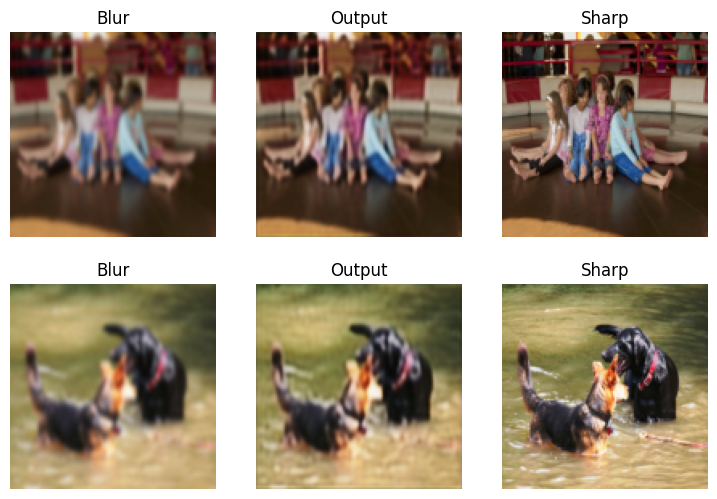

Epoch 2/10: 100%|██████████| 405/405 [01:35<00:00,  4.26it/s]


Epoch 2: Train 0.0281, Val 0.0264, PSNR 28.60, SSIM 0.894


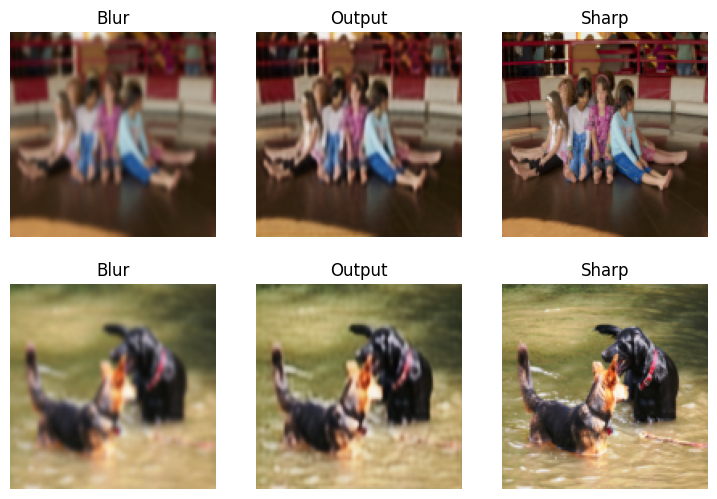

Epoch 3/10: 100%|██████████| 405/405 [01:36<00:00,  4.21it/s]


Epoch 3: Train 0.0257, Val 0.0241, PSNR 29.33, SSIM 0.908


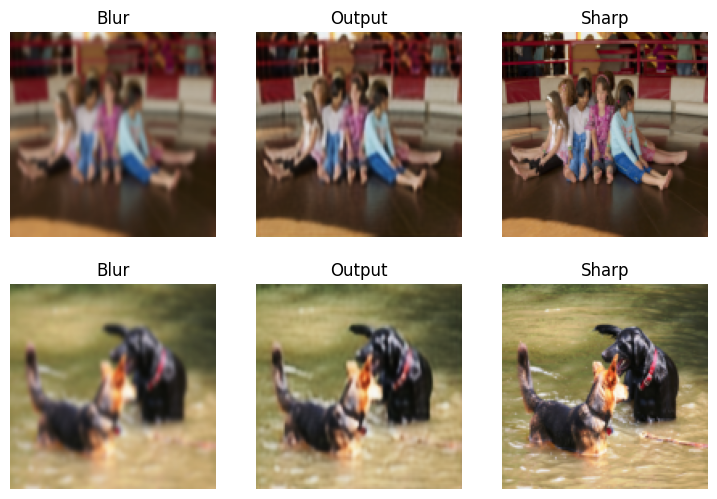

Epoch 4/10: 100%|██████████| 405/405 [01:38<00:00,  4.10it/s]


Epoch 4: Train 0.0237, Val 0.0224, PSNR 29.96, SSIM 0.917


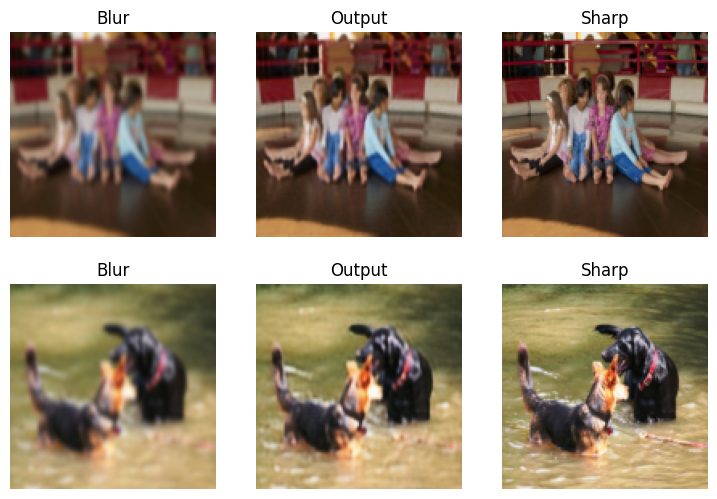

Epoch 5/10: 100%|██████████| 405/405 [01:38<00:00,  4.10it/s]


Epoch 5: Train 0.0225, Val 0.0221, PSNR 30.17, SSIM 0.919


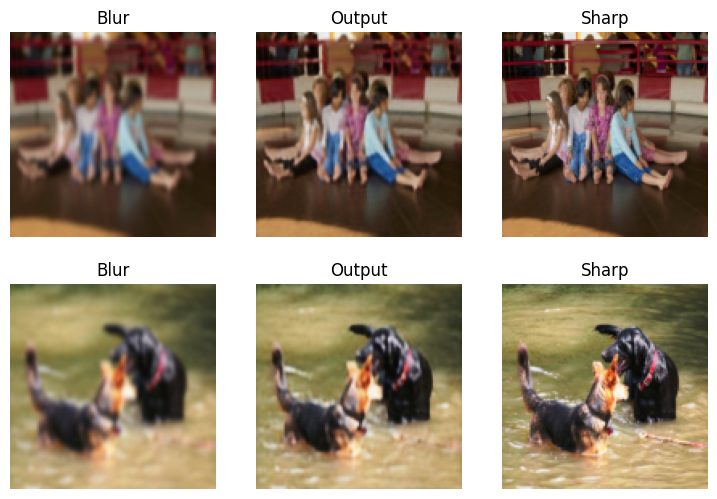

Epoch 6/10: 100%|██████████| 405/405 [01:40<00:00,  4.03it/s]


Epoch 6: Train 0.0214, Val 0.0206, PSNR 30.60, SSIM 0.925


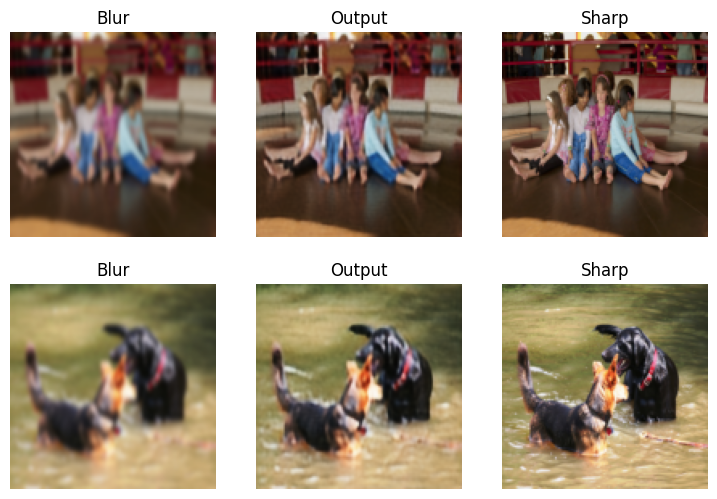

Epoch 7/10: 100%|██████████| 405/405 [01:43<00:00,  3.90it/s]


Epoch 7: Train 0.0214, Val 0.0217, PSNR 30.38, SSIM 0.926


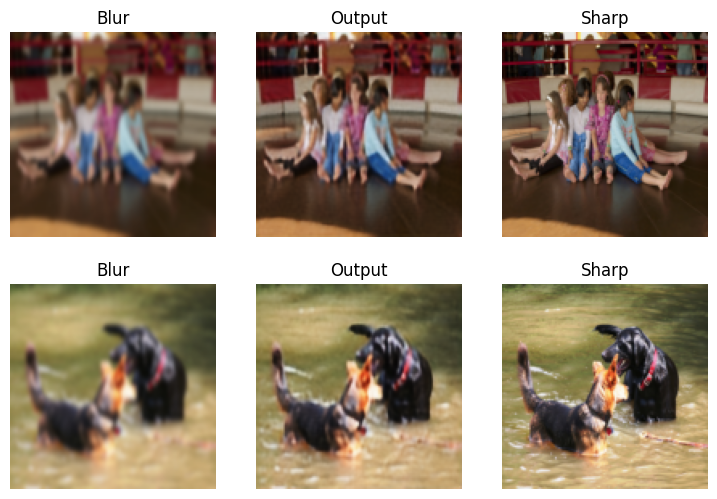

Epoch 8/10: 100%|██████████| 405/405 [01:44<00:00,  3.87it/s]


Epoch 8: Train 0.0206, Val 0.0198, PSNR 30.90, SSIM 0.927


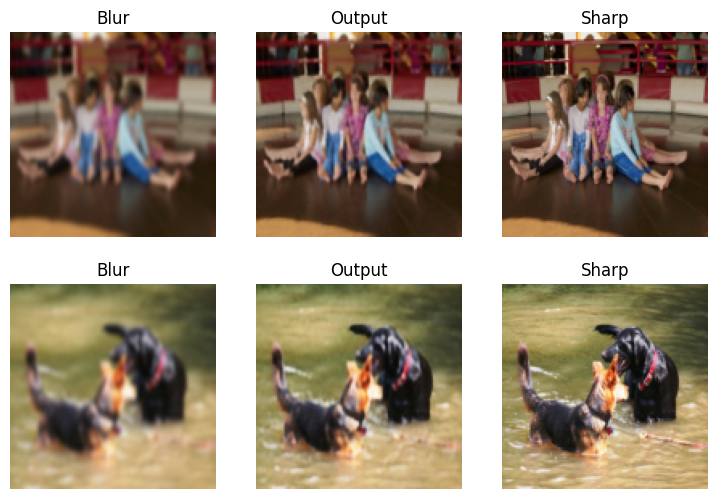

Epoch 9/10: 100%|██████████| 405/405 [01:46<00:00,  3.80it/s]


Epoch 9: Train 0.0203, Val 0.0196, PSNR 31.07, SSIM 0.932


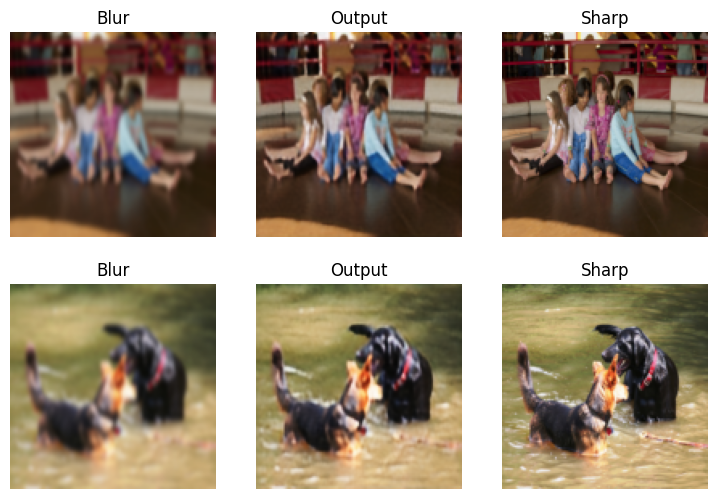

Epoch 10/10: 100%|██████████| 405/405 [01:46<00:00,  3.80it/s]


Epoch 10: Train 0.0203, Val 0.0192, PSNR 31.26, SSIM 0.933


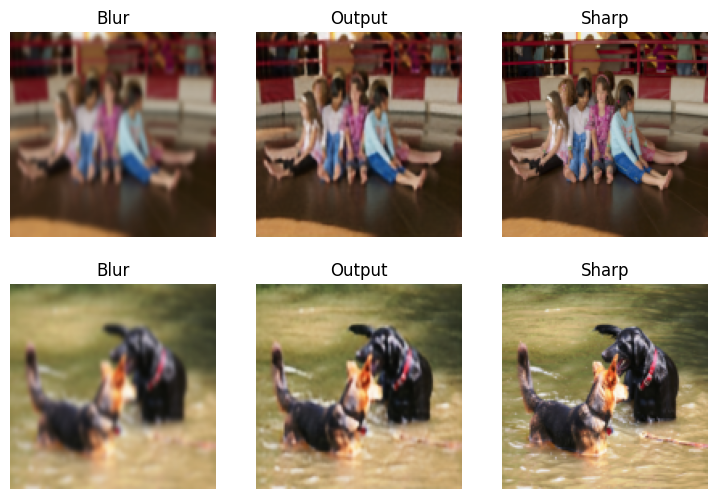

In [12]:
# =============================
# 8. Train Loop
# =============================
model = UNet().to(CFG.device)
optimizer = optim.Adam(model.parameters(), lr=CFG.lr)
criterion = nn.L1Loss()

history = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}

for epoch in range(CFG.epochs):
    model.train()
    train_loss = 0
    for blur, sharp in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG.epochs}"):
        blur, sharp = blur.to(CFG.device), sharp.to(CFG.device)
        optimizer.zero_grad()
        out = model(blur)
        loss = criterion(out, sharp)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()*blur.size(0)
    train_loss /= len(train_loader.dataset)

    # validation
    model.eval()
    val_loss, psnr_score, ssim_score = 0,0,0
    with torch.no_grad():
        for blur, sharp in val_loader:
            blur, sharp = blur.to(CFG.device), sharp.to(CFG.device)
            out = model(blur)
            loss = criterion(out, sharp)
            val_loss += loss.item()*blur.size(0)
            psnr_score += psnr(out, sharp)*blur.size(0)
            ssim_score += ssim(out, sharp)*blur.size(0)
    val_loss /= len(val_loader.dataset)
    psnr_score /= len(val_loader.dataset)
    ssim_score /= len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_psnr"].append(psnr_score)
    history["val_ssim"].append(ssim_score)

    print(f"Epoch {epoch+1}: Train {train_loss:.4f}, Val {val_loss:.4f}, PSNR {psnr_score:.2f}, SSIM {ssim_score:.3f}")
    show_examples(model, val_loader, n=2)


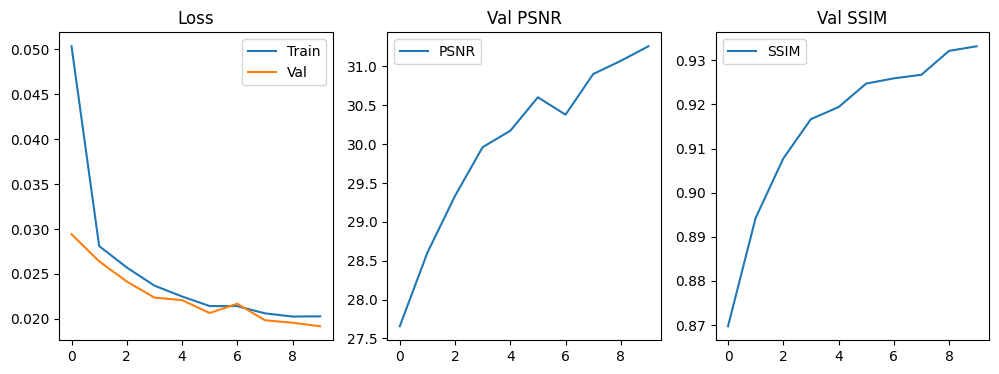

In [13]:
# =============================
# 9. Curves
# =============================
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.plot(history["train_loss"], label="Train"); plt.plot(history["val_loss"], label="Val"); plt.title("Loss"); plt.legend()
plt.subplot(1,3,2); plt.plot(history["val_psnr"], label="PSNR"); plt.title("Val PSNR"); plt.legend()
plt.subplot(1,3,3); plt.plot(history["val_ssim"], label="SSIM"); plt.title("Val SSIM"); plt.legend()
plt.show()


In [14]:
# =====================
# Test Loader
# =====================
test_dataset = BlurDataset(image_dir=CFG.image_dir, split="test")
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

# =====================
# Final Evaluation on Test Set
# =====================
def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_psnr = 0.0
    total_ssim = 0.0
    count = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)

            # Loss
            loss = criterion(y_hat, y).item()
            total_loss += loss

            # Convert to numpy for metrics
            y_np = y.cpu().numpy().transpose(0,2,3,1)
            y_hat_np = y_hat.cpu().numpy().transpose(0,2,3,1)

            for i in range(y_np.shape[0]):
                psnr = peak_signal_noise_ratio(y_np[i], y_hat_np[i], data_range=1.0)
                ssim = structural_similarity(y_np[i], y_hat_np[i], channel_axis=-1, data_range=1.0)
                total_psnr += psnr
                total_ssim += ssim
                count += 1

    return {
        "loss": total_loss / len(loader),
        "psnr": total_psnr / count,
        "ssim": total_ssim / count,
    }

# Run evaluation
metrics = evaluate_model(model, test_loader, criterion, CFG.device)
print("=== Final Test Results ===")
print(f"Loss: {metrics['loss']:.4f}")
print(f"PSNR: {metrics['psnr']:.2f} dB")
print(f"SSIM: {metrics['ssim']:.4f}")

=== Final Test Results ===
Loss: 0.0192
PSNR: 31.26 dB
SSIM: 0.9332
